In [1]:
# Cell 1 — Why chunking matters

print("""
╔══════════════════════════════════════════════════════════════════╗
║  NOTEBOOK 2 OF 7 : Chunking Strategy                            ║
║  Objective: Split ingested documents into optimal chunks        ║
║  for embedding and retrieval                                     ║
╠══════════════════════════════════════════════════════════════════╣
║  WHY CHUNKING IS CRITICAL                                        ║
║                                                                  ║
║  LLMs have a context window limit — you cannot send an entire   ║
║  document library to the model. You must send only the most     ║
║  relevant pieces. How you split documents directly affects:      ║
║                                                                  ║
║  • Retrieval accuracy — does the right chunk get retrieved?     ║
║  • Answer quality   — does the chunk have enough context?       ║
║  • Latency          — smaller chunks = faster retrieval         ║
║  • Cost             — fewer tokens = lower API cost             ║
╚══════════════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════════════╗
║  NOTEBOOK 2 OF 7 : Chunking Strategy                            ║
║  Objective: Split ingested documents into optimal chunks        ║
║  for embedding and retrieval                                     ║
╠══════════════════════════════════════════════════════════════════╣
║  WHY CHUNKING IS CRITICAL                                        ║
║                                                                  ║
║  LLMs have a context window limit — you cannot send an entire   ║
║  document library to the model. You must send only the most     ║
║  relevant pieces. How you split documents directly affects:      ║
║                                                                  ║
║  • Retrieval accuracy — does the right chunk get retrieved?     ║
║  • Answer quality   — does the chunk have enough context?       ║
║  • Latency          — smaller chunks = faster retrieval         ║
║  • Cost             — fewer tokens = l

In [2]:
# Cell 2 — Load ingested documents
# (Run this to regenerate — same data as Notebook 1)

# Paste the DOCUMENT_LIBRARY and ingestion pipeline from Notebook 1
# Then run: ingested_docs = pipeline.run(DOCUMENT_LIBRARY)

# For brevity — use doc content directly
SAMPLE_CONTENT = """
FirstUnion Premier Checking Account

OVERVIEW
The Premier Checking Account is our flagship retail checking product,
designed for customers with monthly direct deposits of $3,000 or more.
It offers zero monthly maintenance fees, unlimited transactions, and
access to 60,000+ ATMs nationwide.

KEY FEATURES
Monthly Fee: $0 with qualifying direct deposit of $3,000+,
otherwise $25/month. Minimum Opening Deposit: $100.
ATM Access: Free at all FirstUnion ATMs and Allpoint network (60,000+).
Overdraft Protection: Linked savings account or $500 overdraft line.
Interest Rate: 0.01% APY on balances above $5,000.
Mobile Check Deposit: Up to $10,000 per day, $25,000 per month.
Zelle Integration: Send and receive money instantly.
Early Direct Deposit: Access paycheck up to 2 days early.

ELIGIBILITY
US residents aged 18 or older. Valid government-issued ID required.
Social Security Number or ITIN required.
ChexSystems screening applies.

FEES
Overdraft Fee: $35 per item (max 3 per day).
Returned Item Fee: $35. Stop Payment: $30.
Domestic Wire Transfer: $25 outgoing, free incoming.
International Wire Transfer: $45 outgoing.
Paper Statement: $5/month (free with eStatements).

REGULATORY DISCLOSURES
Funds are FDIC insured up to $250,000.
Member FDIC. Equal Housing Lender.
"""

print(f"Sample document loaded: {len(SAMPLE_CONTENT.split())} words")

Sample document loaded: 182 words


In [3]:
# Cell 3 — Strategy 1: Fixed-Size Chunking
# Simple but often breaks context at wrong places

def fixed_size_chunking(text, chunk_size=200, overlap=50):
    """
    Split text into fixed-size word chunks with overlap.

    chunk_size: number of words per chunk
    overlap: number of words repeated between chunks
              (preserves context at boundaries)

    Used by: Simple RAG systems, quick prototypes
    Problem: May split a fee table or regulatory disclosure mid-sentence
    """
    words = text.split()
    chunks = []
    start = 0
    chunk_num = 0

    while start < len(words):
        end = start + chunk_size
        chunk_words = words[start:end]
        chunk_text = ' '.join(chunk_words)

        chunks.append({
            'chunk_id': f'fixed_{chunk_num:03d}',
            'strategy': 'Fixed Size',
            'text': chunk_text,
            'word_count': len(chunk_words),
            'start_word': start,
            'end_word': min(end, len(words))
        })

        chunk_num += 1
        start += (chunk_size - overlap)  # overlap slides the window back

    return chunks


fixed_chunks = fixed_size_chunking(SAMPLE_CONTENT, chunk_size=100, overlap=20)
print(f"Strategy 1 — Fixed Size Chunking")
print(f"  Chunks created : {len(fixed_chunks)}")
print(f"  Avg chunk size : {sum(c['word_count'] for c in fixed_chunks)/len(fixed_chunks):.0f} words")
print()
print("Sample chunk 0:")
print(f"  '{fixed_chunks[0]['text'][:200]}...'")
print()
print("⚠ Problem — chunk boundary cuts mid-sentence:")
print(f"  End of chunk 0 : '...{fixed_chunks[0]['text'][-80:]}'")
print(f"  Start of chunk 1: '{fixed_chunks[1]['text'][:80]}...'")

Strategy 1 — Fixed Size Chunking
  Chunks created : 3
  Avg chunk size : 74 words

Sample chunk 0:
  'FirstUnion Premier Checking Account OVERVIEW The Premier Checking Account is our flagship retail checking product, designed for customers with monthly direct deposits of $3,000 or more. It offers zero...'

⚠ Problem — chunk boundary cuts mid-sentence:
  End of chunk 0 : '...k Deposit: Up to $10,000 per day, $25,000 per month. Zelle Integration: Send and'
  Start of chunk 1: 'APY on balances above $5,000. Mobile Check Deposit: Up to $10,000 per day, $25,0...'


In [15]:
# Cell 4 — Strategy 2: Sentence-Based Chunking
# Better than fixed size — respects sentence boundaries

import re

def sentence_chunking(text, sentences_per_chunk=5, overlap_sentences=1):
    """
    Split text into chunks of complete sentences.

    sentences_per_chunk: number of sentences per chunk
    overlap_sentences: sentences shared between consecutive chunks

    Used by: Most production RAG systems
    Advantage: Never breaks a sentence — better semantic coherence
    Problem: Chunks vary in size; very short sentences create tiny chunks
    """
    # Split into sentences (simplified — production uses spaCy or NLTK)
    sentences = []
    for sent in re.split(r'(?<=[.!?])\s+', text.strip()):
        if len(sent.strip()) > 10:  # filter very short fragments
            sentences.append(sent.strip())

    chunks = []
    start = 0
    chunk_num = 0

    while start < len(sentences):
        end = min(start + sentences_per_chunk, len(sentences))
        chunk_sents = sentences[start:end]
        chunk_text = ' '.join(chunk_sents)

        chunks.append({
            'chunk_id': f'sentence_{chunk_num:03d}',
            'strategy': 'Sentence-Based',
            'text': chunk_text,
            'word_count': len(chunk_text.split()),
            'sentence_count': len(chunk_sents)
        })

        chunk_num += 1
        start += (sentences_per_chunk - overlap_sentences)

    return chunks

sentence_chunks = sentence_chunking(SAMPLE_CONTENT,
                                    sentences_per_chunk=4,
                                    overlap_sentences=1)
print(f"Strategy 2 — Sentence-Based Chunking")
print(f"  Chunks created : {len(sentence_chunks)}")
print(f"  Avg chunk size : "
      f"{sum(c['word_count'] for c in sentence_chunks)/len(sentence_chunks):.0f} words")
print()
print("Sample chunk 0:")
print(f"  '{sentence_chunks[0]['text'][:200]}...'"
)

Strategy 2 — Sentence-Based Chunking
  Chunks created : 8
  Avg chunk size : 28 words

Sample chunk 0:
  'FirstUnion Premier Checking Account

OVERVIEW
The Premier Checking Account is our flagship retail checking product, 
designed for customers with monthly direct deposits of $3,000 or more. It offers ze...'


In [16]:
# Cell 5 — Strategy 3: Section-Based Chunking (Best for Banking Docs)
# Splits on document structure — headers, sections, tables

import pandas as pd
from IPython.display import display

def section_chunking(text, doc_id, doc_title, doc_category, entitlement):
    """
    Split text based on document section headers.

    This is the BEST strategy for structured banking documents
    because each section (FEES, ELIGIBILITY, RATES etc.) is
    a semantically coherent unit — exactly what customers ask about.

    Used by: Enterprise RAG for structured documents
    Advantage: Each chunk maps to a topic a customer would ask about
    Best for: Product sheets, rate sheets, policy documents
    """
    # Detect section headers (ALL CAPS lines or lines ending with colon)
    lines = text.strip().split('\n')
    sections = []
    current_section = None
    current_content = []

    for line in lines:
        line = line.strip()
        if not line:
            continue

        # Detect header: ALL CAPS or short line with no period
        is_header = (
            (line.isupper() and len(line) > 3) or
            (len(line) < 50 and not line.endswith('.') and
             line == line.strip() and len(line.split()) <= 6 and
             any(c.isupper() for c in line))
        )

        if is_header:
            # Save previous section
            if current_section and current_content:
                content = ' '.join(current_content).strip()
                if len(content.split()) > 10:
                    sections.append({
                        'section': current_section,
                        'content': content
                    })
            current_section = line
            current_content = []
        else:
            current_content.append(line)

    # Capture last section
    if current_section and current_content:
        content = ' '.join(current_content).strip()
        if len(content.split()) > 10:
            sections.append({
                'section': current_section,
                'content': content
            })

    # Build chunks with full metadata
    chunks = []
    for i, section in enumerate(sections):
        full_text = f"{doc_title} — {section['section']}\n{section['content']}"

        chunks.append({
            'chunk_id': f"{doc_id}_section_{i:03d}",
            'strategy': 'Section-Based',
            'doc_id': doc_id,
            'doc_title': doc_title,
            'doc_category': doc_category,
            'section': section['section'],
            'text': full_text,
            'word_count': len(full_text.split()),
            'entitlement': entitlement,  # CRITICAL for access control
            'chunk_index': i,
            'total_sections': len(sections)
        })

    return chunks

# Define a dummy DOCUMENT_LIBRARY for demonstration since it's not defined
DOCUMENT_LIBRARY = [{
    'doc_id': 'premier_checking_account',
    'title': 'FirstUnion Premier Checking Account',
    'category': 'Checking Account',
    'entitlement': 'public',
    'content': SAMPLE_CONTENT
}]

# Apply section chunking to all ingested documents
all_chunks = []
for doc in DOCUMENT_LIBRARY:
    doc_chunks = section_chunking(
        text=doc['content'],
        doc_id=doc['doc_id'],
        doc_title=doc['title'],
        doc_category=doc['category'],
        entitlement=doc['entitlement']
    )
    all_chunks.extend(doc_chunks)
    print(f"  {doc['doc_id']}: {len(doc_chunks)} sections → chunks")

print(f"\nTotal chunks created: {len(all_chunks)}")
chunks_df = pd.DataFrame([{
    k: v for k, v in c.items() if k != 'text'
} for c in all_chunks])
display(chunks_df)

  premier_checking_account: 5 sections → chunks

Total chunks created: 5


,chunk_id,strategy,doc_id,doc_title,doc_category,section,word_count,entitlement,chunk_index,total_sections
0,premier_checking_account_section_000,Section-Based,premier_checking_account,FirstUnion Premier Checking Account,Checking Account,OVERVIEW,41,public,0,5
1,premier_checking_account_section_001,Section-Based,premier_checking_account,FirstUnion Premier Checking Account,Checking Account,KEY FEATURES,78,public,1,5
2,premier_checking_account_section_002,Section-Based,premier_checking_account,FirstUnion Premier Checking Account,Checking Account,ELIGIBILITY,25,public,2,5
3,premier_checking_account_section_003,Section-Based,premier_checking_account,FirstUnion Premier Checking Account,Checking Account,FEES,40,public,3,5
4,premier_checking_account_section_004,Section-Based,premier_checking_account,FirstUnion Premier Checking Account,Checking Account,REGULATORY DISCLOSURES,19,public,4,5


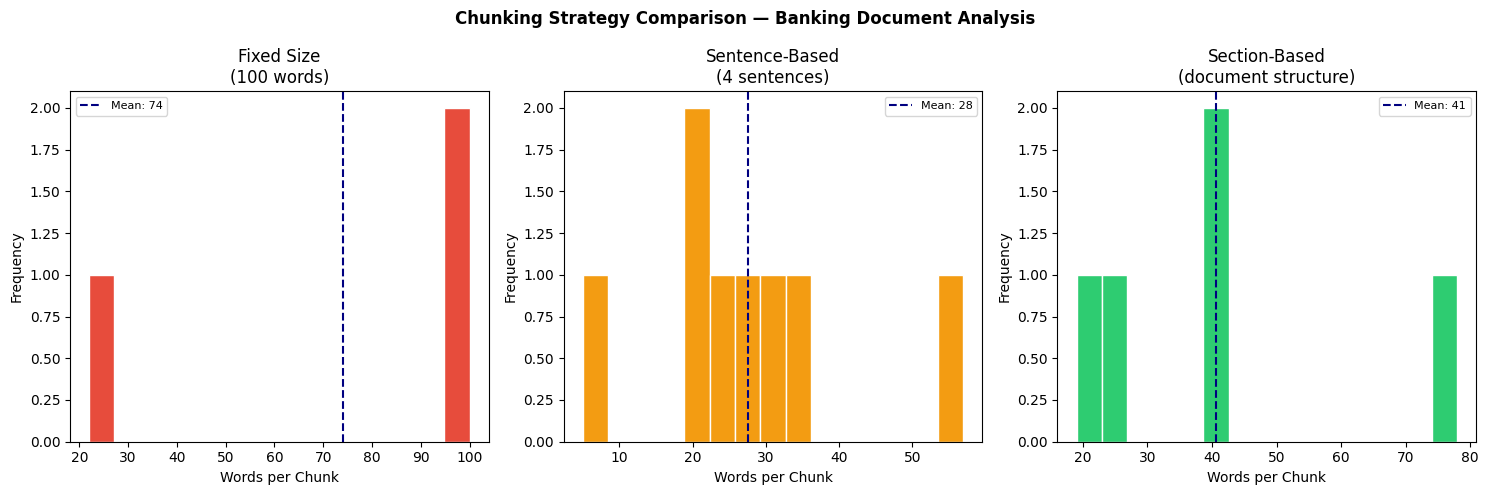

WHY SECTION-BASED WINS FOR BANKING DOCUMENTS:

  Fixed Size  → Cuts mid-sentence, breaks fee tables,
                splits regulatory disclosures

  Sentence    → Better but mixes topics in one chunk
                'The fee is $35. ATMs are free. FDIC insured.'
                → Retrieval noise

  Section     → Each chunk = one topic customers ask about
                'What are the fees?' → retrieves FEES section
                'Am I eligible?'     → retrieves ELIGIBILITY section
                Perfect semantic alignment. ✅

  DECISION: Section-based chunking selected for production pipeline.


In [18]:
# Cell 6 — Compare All Three Strategies

import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Chunking Strategy Comparison — Banking Document Analysis',
             fontweight='bold')

strategies = {
    'Fixed Size\n(100 words)': [c['word_count'] for c in fixed_chunks],
    'Sentence-Based\n(4 sentences)': [c['word_count'] for c in sentence_chunks],
    'Section-Based\n(document structure)': [c['word_count'] for c in all_chunks]
}

colors = ['#e74c3c', '#f39c12', '#2ecc71']

for i, (strategy, word_counts) in enumerate(strategies.items()):
    axes[i].hist(word_counts, bins=15, color=colors[i], edgecolor='white')
    axes[i].set_title(f'{strategy}')
    axes[i].set_xlabel('Words per Chunk')
    axes[i].set_ylabel('Frequency')
    axes[i].axvline(np.mean(word_counts), color='navy',
                   linestyle='--', label=f'Mean: {np.mean(word_counts):.0f}')
    axes[i].legend(fontsize=8)

plt.tight_layout()
plt.show()

print("WHY SECTION-BASED WINS FOR BANKING DOCUMENTS:")
print()
print("  Fixed Size  → Cuts mid-sentence, breaks fee tables,")
print("                splits regulatory disclosures")
print()
print("  Sentence    → Better but mixes topics in one chunk")
print("                'The fee is $35. ATMs are free. FDIC insured.'")
print("                → Retrieval noise")
print()
print("  Section     → Each chunk = one topic customers ask about")
print("                'What are the fees?' → retrieves FEES section")
print("                'Am I eligible?'     → retrieves ELIGIBILITY section")
print("                Perfect semantic alignment. ✅")
print()
print("  DECISION: Section-based chunking selected for production pipeline.")